In [13]:
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [3]:
with open("./data/26-09-09-10-45_history_frozen_H2_molecule_K4.pkl", "rb") as f:
    history = pickle.load(f)
history.keys()


dict_keys(['steps', 'logpsi_mean', 'grad_norm_raw', 'grad_norm_natural', 'loss', 'save_interval', 'Energy_levels', 'err', 'n_active_params', 'qgt_size', 'frozen_set_history', 'frozen_set', 'params'])

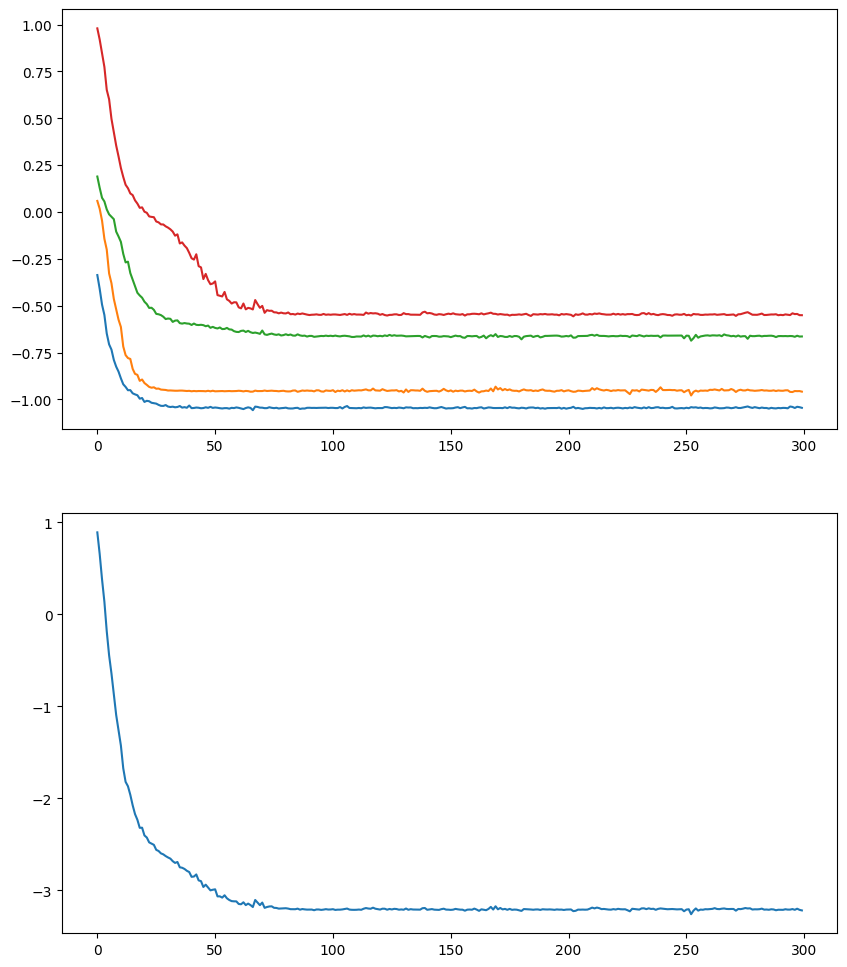

In [14]:
fig,axs = plt.subplots(2, 1, figsize=(10, 12))
axs[0].plot(history['steps'],history["Energy_levels"])
axs[1].plot(history['steps'],history["loss"])

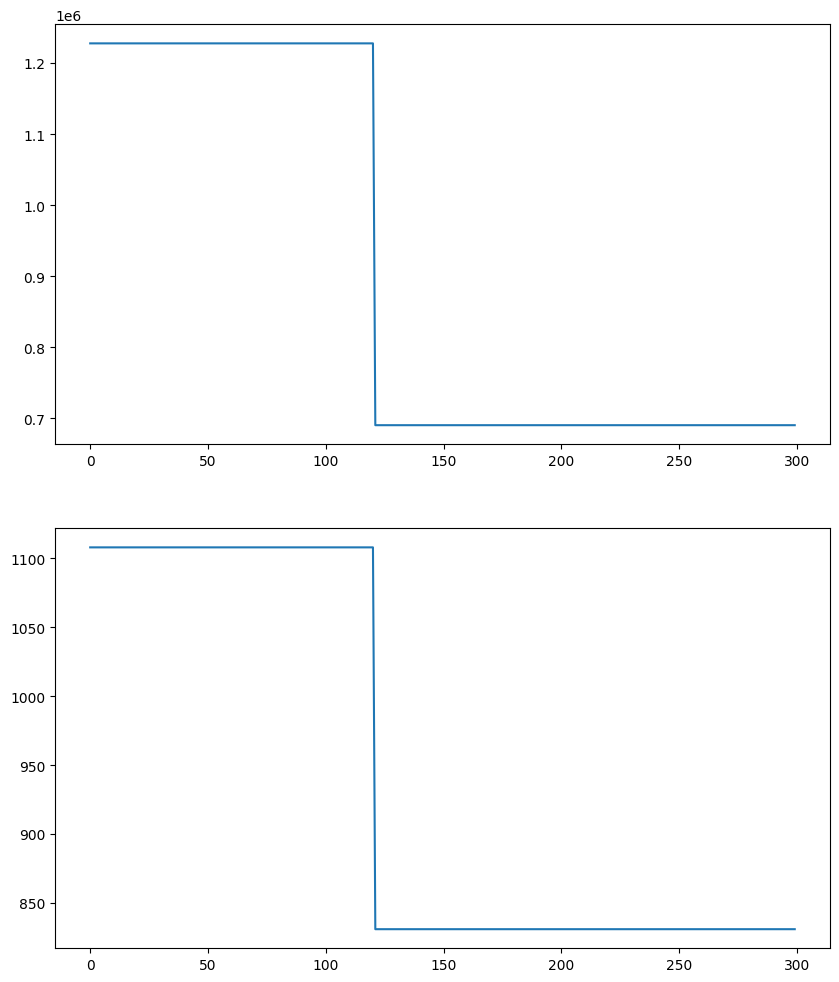

In [16]:
fig,axs = plt.subplots(2, 1, figsize=(10, 12))
axs[0].plot(history['steps'],history["qgt_size"])
axs[1].plot(history['steps'],history["n_active_params"])


In [ ]:
import os
os.makedirs("./日志", exist_ok=True)
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(8, 6))
step_index = 299
steps_slice = steps_history[:step_index]
energy_arr = np.array(Energy_levels_history)[:step_index, :]
color_palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

# ============ 主图：能量曲线 ============
for energy_index in range(K):
    c = color_palette[energy_index % len(color_palette)]
    ax.plot(steps_slice, energy_arr[:, energy_index],
            marker="o", markersize=2.5, markevery=10,
            linewidth=1.2, color=c, label=f"$E_{energy_index}$ (NES-VMC)")
    ax.axhline(exact_eigvals[energy_index], color=c, linestyle="--", alpha=0.7, label=f"$E_{energy_index}$ (CAS Exact)")

ax.set_ylim(-1.5, 0.0)
ax.set_xlabel("Optimization step")
ax.set_ylabel("Energy Level (Ha)")
ax.legend(loc="lower right")
ax.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Curve ')
# ============ 内嵌子图 inset_axes ============
# 参数：宽度40%主图宽度，高度35%主图高度；位置 upper left / upper right
ax_inset = inset_axes(
    ax,
    width="40%",
    height="25%",
    loc="lower left",
    bbox_to_anchor=(0.54, 0.7, 1, 1),   # 4‑tuple！
    bbox_transform=ax.transAxes,
    borderpad=0
)

#ax_inset.set_title(f'NES-VMC (K={K}) LiH Energy Levels Difference (Inset)')

# 绘制误差 ΔE = E_vmc − E_exact
for energy_index in range(K):
    c = color_palette[energy_index % len(color_palette)]
    delta_E = energy_arr[:, energy_index] - exact_eigvals[energy_index]
    ax_inset.plot(steps_slice, delta_E, color=c, marker=".", markersize=1.5, markevery=5, linewidth=0.8)
    ax_inset.set_ylim(0.0, 0.002)

ax_inset.set_xlabel("Step", fontsize=8)
ax_inset.set_ylabel(r"$\Delta E$ (Ha)", fontsize=8)
ax_inset.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Difference', fontsize=8)
ax_inset.tick_params(axis='both', labelsize=7)


# ---- 新增：0.0016以下浅蓝色填充 + 阈值虚线 ----
ax_inset.axhspan(ymin=0.0, ymax=0.0016, color="#b8e1ff", alpha=0.4, zorder=0)
ax_inset.axhline(y=0.0016, color="steelblue", linestyle="--", lw=0.7, zorder=1)

ax_inset.set_xlabel("Step", fontsize=8)
ax_inset.set_ylabel(r"$\Delta E$ (Ha)", fontsize=8)
ax_inset.set_title(f'NES-VMC (K={K}) $H_2$ Energy Levels Difference', fontsize=8)
ax_inset.tick_params(axis='both', labelsize=7)

# 误差非常推荐log尺度！看收敛下降；如果有负误差就不能log，可以注释
# ax_inset.set_yscale("log")
ax_inset.grid(alpha=0.2)

# fig.savefig(f'./日志/[能量]{time_str}_Energy_curve_all V2.pdf', bbox_inches="tight")
# fig.savefig(f'./日志/[能量]{time_str}_Energy_curve_all V2.png', bbox_inches="tight")
# plt.close(fig)


NameError: name 'os' is not defined